In [1]:
from pathlib import Path
import json
import sys

project_root = Path.cwd().resolve().parents[1]
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.eda.mask_level_eda import (
    summarize_mask_folder,
    summarize_mask_file,
    plot_label_sizes_single_case,
    plot_dataset_nonzero_fraction,
    plot_label_frequency_across_files,
    plot_slice_occupancy,
    show_mask_slice,
)

from src.eda.visualize_masks import show_nifti_overlay_from_paths

In [2]:
config_path = project_root / "configs" / "datasets" / "public_dataset.json"

with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)

totalseg_root = Path(config["totalseg_root"])
public_root = Path(config["public_root"])

print("totalseg_root exists:", totalseg_root.exists(), totalseg_root)
print("public_root exists:", public_root.exists(), public_root)

totalseg_root exists: True C:\Users\P102832\Downloads\thesis_segmentation\data\interim\public_same_format\totalsegmentator_ml
public_root exists: True C:\Users\P102832\Downloads\thesis_segmentation\data\raw\public_same_format\NIFTI


In [3]:
all_summary_df, all_labels_df, mask_paths = summarize_mask_folder(totalseg_root)

print("number of mask files found:", len(mask_paths))
all_summary_df.head()

number of mask files found: 4


,file_name,shape_x,shape_y,shape_z,spacing_x,spacing_y,spacing_z,n_labels_present,label_ids_present,nonzero_voxels,...,slices_with_mask_axis2,bbox_x_min,bbox_x_max,bbox_y_min,bbox_y_max,bbox_z_min,bbox_z_max,bbox_size_x,bbox_size_y,bbox_size_z
0,case101_day20.nii.gz,266,266,144,1.5,1.5,3.0,28,"1,2,3,5,6,10,11,12,13,14,15,18,19,20,21,22,23,...",1589376,...,144,40,247,70,223,0,143,208,154,144
1,case101_day22.nii.gz,266,266,144,1.5,1.5,3.0,34,"1,2,3,5,6,10,11,12,13,14,15,18,19,20,21,22,23,...",1589420,...,144,22,239,68,217,0,143,218,150,144
2,case101_day26.nii.gz,266,266,144,1.5,1.5,3.0,32,"1,2,3,5,6,10,11,12,13,14,15,18,19,20,21,22,23,...",1600896,...,144,14,243,68,215,0,143,230,148,144
3,case9_day22.nii.gz,360,310,144,1.5,1.5,3.0,35,"1,2,3,5,6,7,10,11,12,13,15,16,18,19,20,21,22,2...",1423548,...,144,32,257,54,241,0,143,226,188,144


In [4]:
all_labels_df.head(20)

,label_id,label_name,voxel_count,fraction_of_labeled_voxels,fraction_of_all_voxels,file_name
0,10,lung_left,437892,0.275512,0.042978,case101_day20.nii.gz
1,11,lung_right,411572,0.258952,0.040394,case101_day20.nii.gz
2,5,liver,89560,0.056349,0.008790,case101_day20.nii.gz
3,15,colon,86224,0.054250,0.008463,case101_day20.nii.gz
4,6,stomach,85688,0.053913,0.008410,case101_day20.nii.gz
5,22,heart,75468,0.047483,0.007407,case101_day20.nii.gz
6,47,autochthon_right,53284,0.033525,0.005230,case101_day20.nii.gz
7,46,autochthon_left,52712,0.033165,0.005173,case101_day20.nii.gz
8,19,vertebrae,49004,0.030832,0.004810,case101_day20.nii.gz
9,1,spleen,32740,0.020599,0.003213,case101_day20.nii.gz


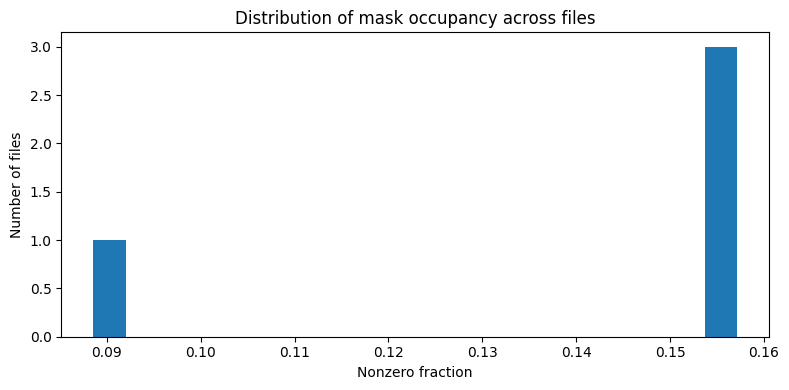

In [5]:
plot_dataset_nonzero_fraction(all_summary_df)

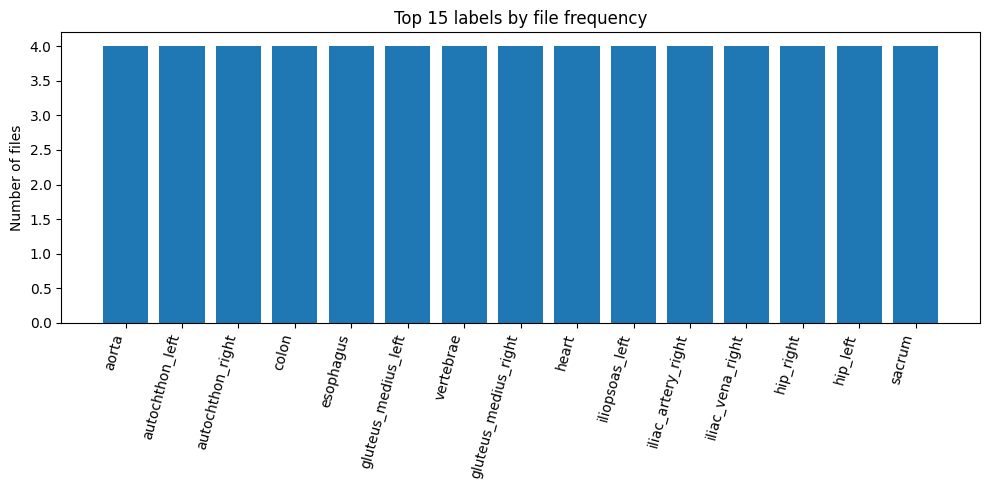

In [6]:
plot_label_frequency_across_files(all_labels_df, top_n=15)

In [7]:
example_mask_path = mask_paths[0]
print("example mask:", example_mask_path.name)

summary_df, labels_df, mask, img, label_map = summarize_mask_file(example_mask_path)

summary_df

example mask: case101_day20.nii.gz


,file_name,shape_x,shape_y,shape_z,spacing_x,spacing_y,spacing_z,n_labels_present,label_ids_present,nonzero_voxels,...,slices_with_mask_axis2,bbox_x_min,bbox_x_max,bbox_y_min,bbox_y_max,bbox_z_min,bbox_z_max,bbox_size_x,bbox_size_y,bbox_size_z
0,case101_day20.nii.gz,266,266,144,1.5,1.5,3.0,28,"1,2,3,5,6,10,11,12,13,14,15,18,19,20,21,22,23,...",1589376,...,144,40,247,70,223,0,143,208,154,144


In [8]:
labels_df.head(20)

,label_id,label_name,voxel_count,fraction_of_labeled_voxels,fraction_of_all_voxels
0,10,lung_left,437892,0.275512,0.042978
1,11,lung_right,411572,0.258952,0.040394
2,5,liver,89560,0.056349,0.008790
3,15,colon,86224,0.054250,0.008463
4,6,stomach,85688,0.053913,0.008410
5,22,heart,75468,0.047483,0.007407
6,47,autochthon_right,53284,0.033525,0.005230
7,46,autochthon_left,52712,0.033165,0.005173
8,19,vertebrae,49004,0.030832,0.004810
9,1,spleen,32740,0.020599,0.003213


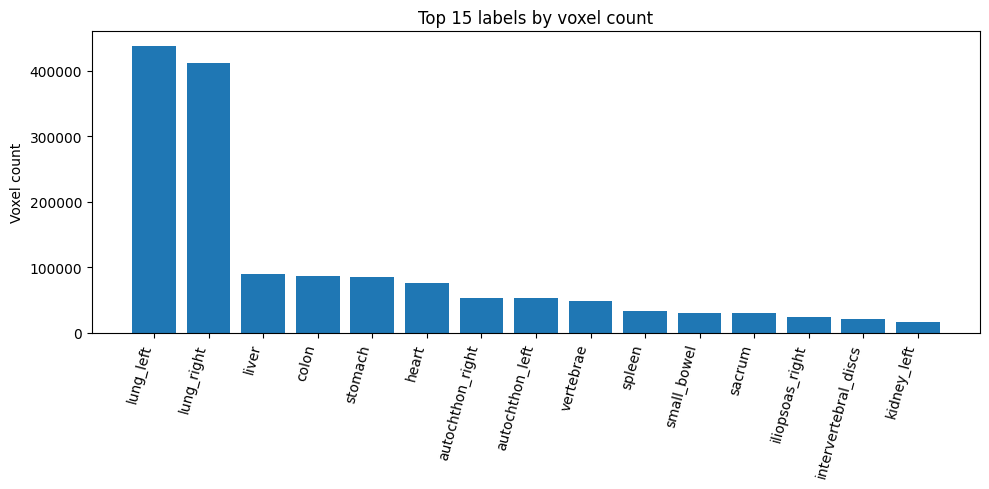

In [9]:
plot_label_sizes_single_case(labels_df, top_n=15)

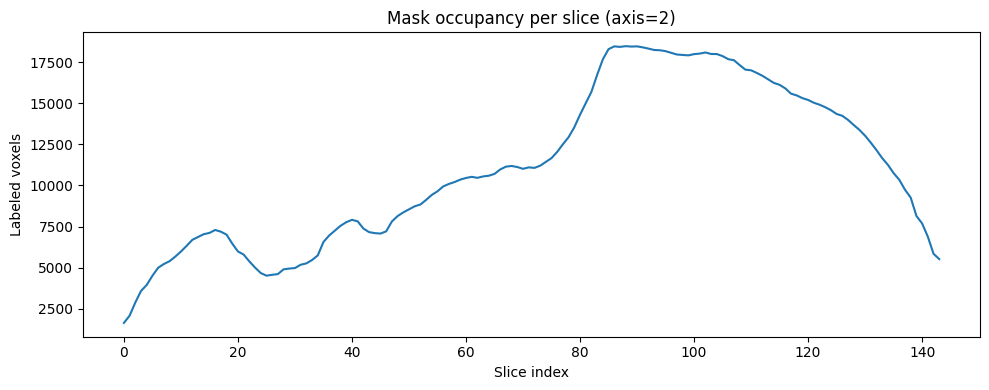

In [10]:
plot_slice_occupancy(mask, axis=2)

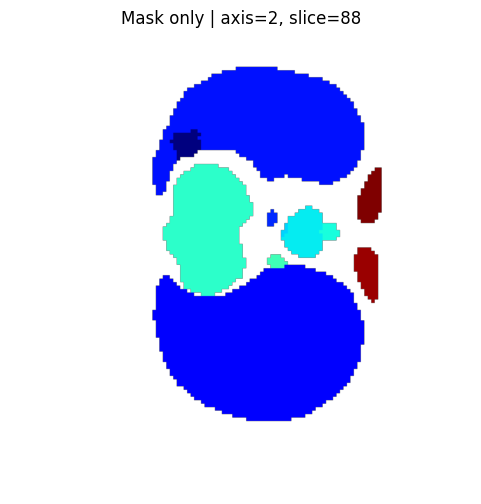

In [11]:
show_mask_slice(mask, axis=2)

scan exists: True C:\Users\P102832\Downloads\thesis_segmentation\data\raw\public_same_format\NIFTI\case101_day20.nii.gz
mask exists: True C:\Users\P102832\Downloads\thesis_segmentation\data\interim\public_same_format\totalsegmentator_ml\case101_day20.nii.gz


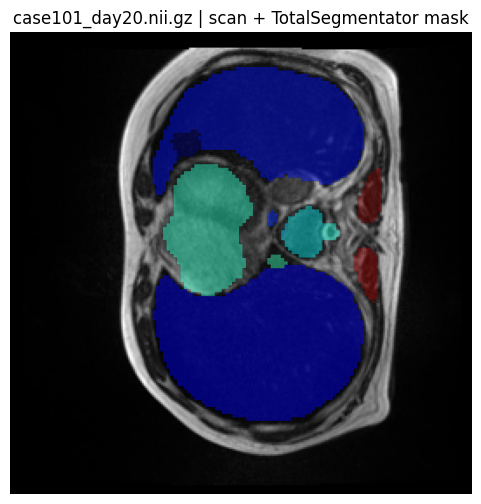

In [12]:
case_name = example_mask_path.name
scan_path = public_root / case_name

print("scan exists:", scan_path.exists(), scan_path)
print("mask exists:", example_mask_path.exists(), example_mask_path)

show_nifti_overlay_from_paths(
    scan_path=scan_path,
    mask_path=example_mask_path,
    axis=2,
    slice_idx=None,
    title=f"{case_name} | scan + TotalSegmentator mask"
)

In [15]:
from pathlib import Path
import sys
import importlib

project_root = Path.cwd().resolve().parents[1]
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.eda.mask_level_eda as mask_level_eda
importlib.reload(mask_level_eda)

print("module file:", mask_level_eda.__file__)
print("has GI_LABELS_TOTAL_MR:", hasattr(mask_level_eda, "GI_LABELS_TOTAL_MR"))
print("GI_LABELS_TOTAL_MR:", getattr(mask_level_eda, "GI_LABELS_TOTAL_MR", None))

module file: C:\Users\P102832\Downloads\thesis_segmentation\src\eda\mask_level_eda.py
has GI_LABELS_TOTAL_MR: True
GI_LABELS_TOTAL_MR: {6: 'stomach', 13: 'small_bowel', 15: 'colon'}


In [16]:
from src.eda.mask_level_eda import (
    GI_LABELS_TOTAL_MR,
    summarize_selected_labels_folder,
    summarize_selected_labels_file,
    plot_selected_label_sizes_single_case,
    plot_selected_label_volumes_single_case,
    plot_selected_label_frequency_across_files,
)

In [17]:
from pathlib import Path
import json
import sys

project_root = Path.cwd().resolve().parents[1]
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.eda.mask_level_eda import (
    GI_LABELS_TOTAL_MR,
    summarize_selected_labels_folder,
    summarize_selected_labels_file,
    plot_selected_label_sizes_single_case,
    plot_selected_label_volumes_single_case,
    plot_selected_label_frequency_across_files,
)

from src.eda.visualize_masks import show_nifti_overlay_from_paths

In [18]:
config_path = project_root / "configs" / "datasets" / "public_dataset.json"

with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)

totalseg_root = Path(config["totalseg_root"])
public_root = Path(config["public_root"])

gi_summary_df, gi_labels_df, gi_spans_df, mask_paths = summarize_selected_labels_folder(
    totalseg_root,
    selected_labels=GI_LABELS_TOTAL_MR,
)

print("number of mask files found:", len(mask_paths))
gi_summary_df

number of mask files found: 4


,file_name,shape_x,shape_y,shape_z,n_selected_labels_present,selected_nonzero_voxels,selected_nonzero_fraction
0,case101_day20.nii.gz,266,266,144,3,201980,0.019824
1,case101_day22.nii.gz,266,266,144,3,220428,0.021634
2,case101_day26.nii.gz,266,266,144,3,251912,0.024724
3,case9_day22.nii.gz,360,310,144,3,200272,0.012462


In [19]:
gi_labels_df

,label_id,label_name,voxel_count,present,fraction_of_selected_labeled_voxels,fraction_of_all_voxels,volume_mm3,volume_ml,file_name
0,15,colon,86224,True,0.426894,0.008463,582012.0,582.012,case101_day20.nii.gz
1,6,stomach,85688,True,0.424240,0.008410,578394.0,578.394,case101_day20.nii.gz
2,13,small_bowel,30068,True,0.148866,0.002951,202959.0,202.959,case101_day20.nii.gz
3,15,colon,89688,True,0.406881,0.008803,605394.0,605.394,case101_day22.nii.gz
4,6,stomach,75908,True,0.344366,0.007450,512379.0,512.379,case101_day22.nii.gz
5,13,small_bowel,54832,True,0.248752,0.005382,370116.0,370.116,case101_day22.nii.gz
6,15,colon,100708,True,0.399775,0.009884,679779.0,679.779,case101_day26.nii.gz
7,6,stomach,82592,True,0.327861,0.008106,557496.0,557.496,case101_day26.nii.gz
8,13,small_bowel,68612,True,0.272365,0.006734,463131.0,463.131,case101_day26.nii.gz
9,15,colon,99880,True,0.498722,0.006215,674190.0,674.190,case9_day22.nii.gz


In [20]:
gi_spans_df

,label_id,label_name,first_slice,last_slice,n_slices_present,best_slice,file_name
0,6,stomach,46,80,35,67,case101_day20.nii.gz
1,13,small_bowel,0,45,46,7,case101_day20.nii.gz
2,15,colon,12,74,63,39,case101_day20.nii.gz
3,6,stomach,50,86,37,71,case101_day22.nii.gz
4,13,small_bowel,0,63,56,2,case101_day22.nii.gz
5,15,colon,6,70,65,44,case101_day22.nii.gz
6,6,stomach,49,86,38,67,case101_day26.nii.gz
7,13,small_bowel,0,61,58,5,case101_day26.nii.gz
8,15,colon,8,77,70,42,case101_day26.nii.gz
9,6,stomach,72,103,32,81,case9_day22.nii.gz


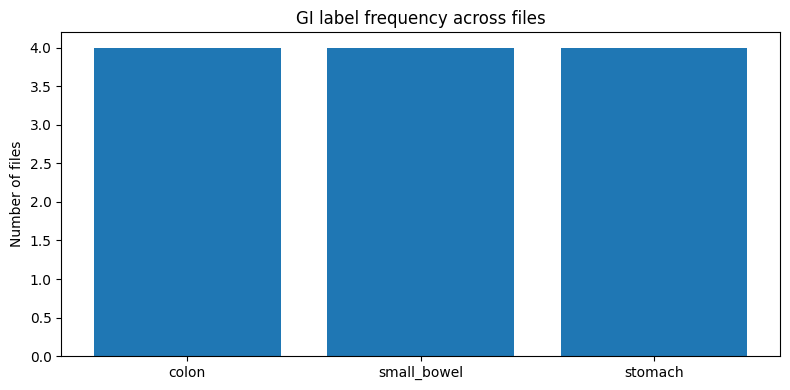

In [21]:
plot_selected_label_frequency_across_files(gi_labels_df)

In [22]:
example_mask_path = mask_paths[0]

single_summary_df, single_labels_df, single_spans_df, gi_mask, gi_img = summarize_selected_labels_file(
    example_mask_path,
    selected_labels=GI_LABELS_TOTAL_MR,
)

single_summary_df

,file_name,shape_x,shape_y,shape_z,n_selected_labels_present,selected_nonzero_voxels,selected_nonzero_fraction
0,case101_day20.nii.gz,266,266,144,3,201980,0.019824


In [23]:
single_labels_df

,label_id,label_name,voxel_count,present,fraction_of_selected_labeled_voxels,fraction_of_all_voxels,volume_mm3,volume_ml
0,15,colon,86224,True,0.426894,0.008463,582012.0,582.012
1,6,stomach,85688,True,0.424240,0.008410,578394.0,578.394
2,13,small_bowel,30068,True,0.148866,0.002951,202959.0,202.959


In [24]:
single_spans_df

,label_id,label_name,first_slice,last_slice,n_slices_present,best_slice
0,6,stomach,46,80,35,67
1,13,small_bowel,0,45,46,7
2,15,colon,12,74,63,39


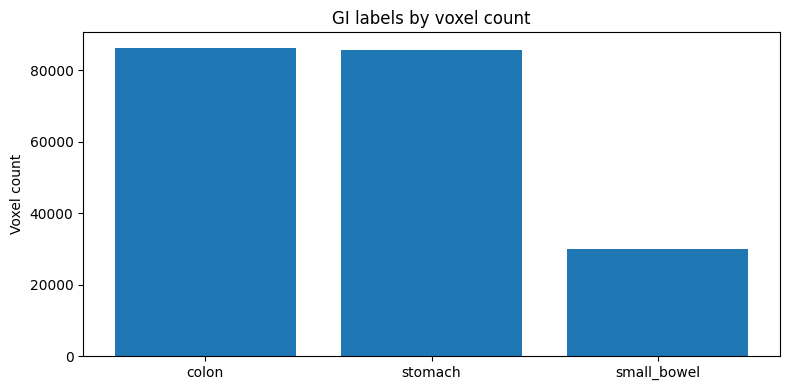

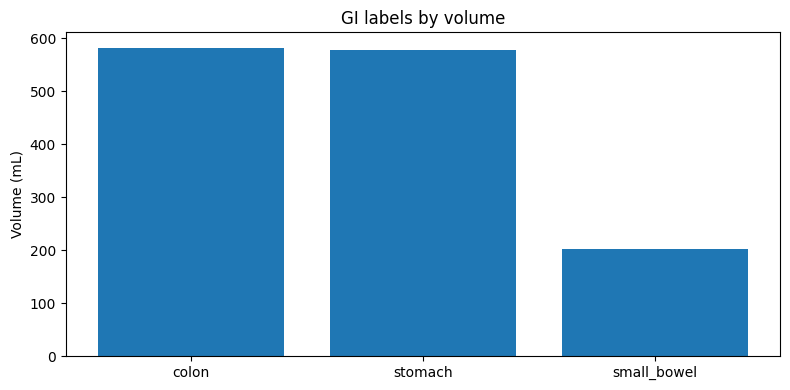

In [25]:
plot_selected_label_sizes_single_case(single_labels_df)
plot_selected_label_volumes_single_case(single_labels_df)

In [29]:
import importlib
import src.eda.visualize_masks as visualize_masks

importlib.reload(visualize_masks)

from src.eda.visualize_masks import load_nifti, show_nifti_overlay_from_arrays

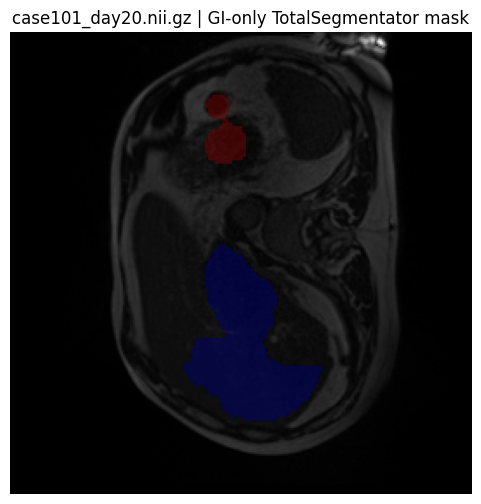

In [30]:
from src.eda.visualize_masks import load_nifti, show_nifti_overlay_from_arrays

case_name = example_mask_path.name
scan_path = public_root / case_name

scan_volume, _ = load_nifti(scan_path)

show_nifti_overlay_from_arrays(
    scan_volume=scan_volume,
    mask_volume=gi_mask,
    axis=2,
    slice_idx=None,
    title=f"{case_name} | GI-only TotalSegmentator mask"
)

In [32]:
from pathlib import Path
import sys
import importlib

project_root = Path.cwd().resolve().parents[1]
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.eda.mask_level_eda as mask_level_eda
importlib.reload(mask_level_eda)

print(mask_level_eda.__file__)
print(hasattr(mask_level_eda, "build_case_gi_summary_table"))
print(hasattr(mask_level_eda, "build_case_gi_summary_sentence"))
print(hasattr(mask_level_eda, "get_label_id_by_name"))
print(hasattr(mask_level_eda, "extract_single_label_mask"))

C:\Users\P102832\Downloads\thesis_segmentation\src\eda\mask_level_eda.py
True
True
True
True


In [33]:
from src.eda.mask_level_eda import (
    GI_LABELS_TOTAL_MR,
    summarize_selected_labels_file,
    summarize_selected_labels_folder,
    build_case_gi_summary_table,
    build_case_gi_summary_sentence,
    get_label_id_by_name,
    extract_single_label_mask,
)

In [34]:
case_name = example_mask_path.name

case_gi_summary_table = build_case_gi_summary_table(
    single_labels_df,
    single_spans_df,
    organ_order=("colon", "stomach", "small_bowel"),
)

case_gi_summary_sentence = build_case_gi_summary_sentence(
    single_labels_df,
    single_spans_df,
    file_name=case_name,
    organ_order=("colon", "stomach", "small_bowel"),
)

print(case_gi_summary_sentence)
case_gi_summary_table

case101_day20.nii.gz: colon 582.0 mL across 63 slices; stomach 578.4 mL across 35 slices; small_bowel 203.0 mL across 46 slices.


,label_id,label_name,voxel_count,volume_ml,first_slice,last_slice,n_slices_present,best_slice
0,15,colon,86224,582.012,12,74,63,39
1,6,stomach,85688,578.394,46,80,35,67
2,13,small_bowel,30068,202.959,0,45,46,7


stomach: label_id=6, best_slice=67


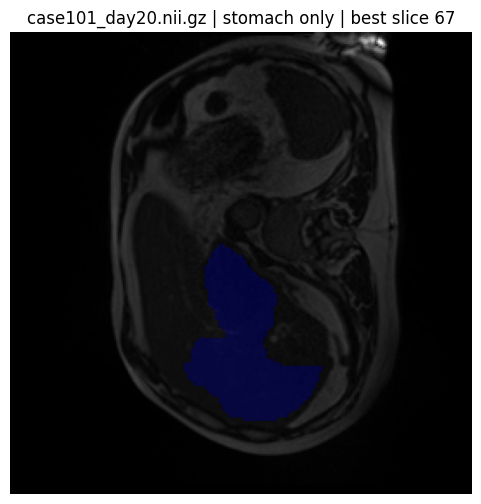

small_bowel: label_id=13, best_slice=7


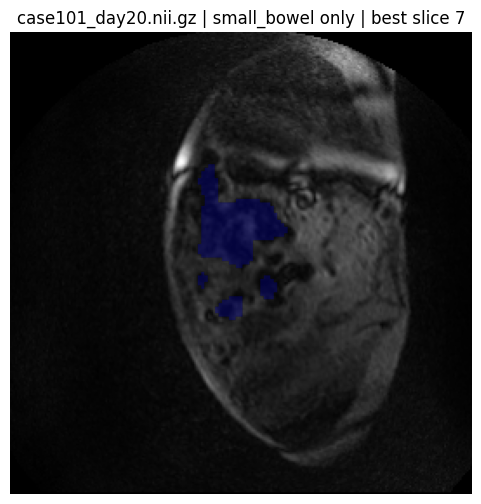

colon: label_id=15, best_slice=39


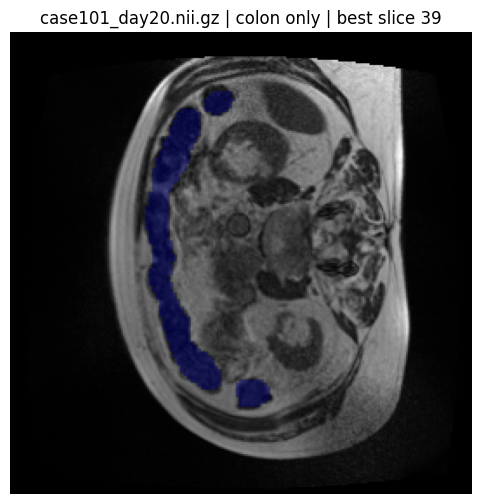

In [35]:
case_name = example_mask_path.name
scan_path = public_root / case_name

scan_volume, _ = load_nifti(scan_path)

organ_order = ["stomach", "small_bowel", "colon"]

for organ_name in organ_order:
    label_id = get_label_id_by_name(GI_LABELS_TOTAL_MR, organ_name)

    organ_mask = extract_single_label_mask(gi_mask, label_id)

    organ_best_slice = int(
        single_spans_df.loc[single_spans_df["label_name"] == organ_name, "best_slice"].iloc[0]
    )

    print(f"{organ_name}: label_id={label_id}, best_slice={organ_best_slice}")

    show_nifti_overlay_from_arrays(
        scan_volume=scan_volume,
        mask_volume=organ_mask,
        axis=2,
        slice_idx=organ_best_slice,
        title=f"{case_name} | {organ_name} only | best slice {organ_best_slice}"
    )

In [37]:
import pandas as pd

all_case_summaries = []

for mask_path in mask_paths:
    case_name = mask_path.name

    single_summary_df, single_labels_df, single_spans_df, gi_mask, gi_img = summarize_selected_labels_file(
        mask_path,
        selected_labels=GI_LABELS_TOTAL_MR,
    )

    sentence = build_case_gi_summary_sentence(
        single_labels_df,
        single_spans_df,
        file_name=case_name,
        organ_order=("colon", "stomach", "small_bowel"),
    )

    case_table = build_case_gi_summary_table(
        single_labels_df,
        single_spans_df,
        organ_order=("colon", "stomach", "small_bowel"),
    ).copy()

    wide_row = {"file_name": case_name, "summary_sentence": sentence}

    for _, row in case_table.iterrows():
        organ = row["label_name"]
        wide_row[f"{organ}_voxel_count"] = int(row["voxel_count"])
        wide_row[f"{organ}_volume_ml"] = float(row["volume_ml"])
        wide_row[f"{organ}_first_slice"] = int(row["first_slice"])
        wide_row[f"{organ}_last_slice"] = int(row["last_slice"])
        wide_row[f"{organ}_n_slices_present"] = int(row["n_slices_present"])
        wide_row[f"{organ}_best_slice"] = int(row["best_slice"])

    all_case_summaries.append(wide_row)

all_case_summary_df = pd.DataFrame(all_case_summaries)
all_case_summary_df

,file_name,summary_sentence,colon_voxel_count,colon_volume_ml,colon_first_slice,colon_last_slice,colon_n_slices_present,colon_best_slice,stomach_voxel_count,stomach_volume_ml,stomach_first_slice,stomach_last_slice,stomach_n_slices_present,stomach_best_slice,small_bowel_voxel_count,small_bowel_volume_ml,small_bowel_first_slice,small_bowel_last_slice,small_bowel_n_slices_present,small_bowel_best_slice
0,case101_day20.nii.gz,case101_day20.nii.gz: colon 582.0 mL across 63...,86224,582.012,12,74,63,39,85688,578.394,46,80,35,67,30068,202.959,0,45,46,7
1,case101_day22.nii.gz,case101_day22.nii.gz: colon 605.4 mL across 65...,89688,605.394,6,70,65,44,75908,512.379,50,86,37,71,54832,370.116,0,63,56,2
2,case101_day26.nii.gz,case101_day26.nii.gz: colon 679.8 mL across 70...,100708,679.779,8,77,70,42,82592,557.496,49,86,38,67,68612,463.131,0,61,58,5
3,case9_day22.nii.gz,case9_day22.nii.gz: colon 674.2 mL across 80 s...,99880,674.190,2,82,80,55,29992,202.446,72,103,32,81,70400,475.200,0,78,72,23
